In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -------------------------
# 1. Generate Gaussian mixture data
# -------------------------
n = 1000
d = 100
k = 4  # mixture components

means = torch.randn(k, d) * 2.0
cov = torch.eye(d)

components = torch.randint(0, k, (n,))
X = torch.stack([torch.distributions.MultivariateNormal(
    means[c], cov).sample() for c in components])

# regression target (smooth function of x)
y = torch.sin(X[:, 0]) + 0.1 * torch.randn(n)
y = y.unsqueeze(1)

# -------------------------
# 2. Model definitions
# -------------------------
def make_mlp(widths):
    layers = []
    for i in range(len(widths) - 2):
        layers.append(nn.Linear(widths[i], widths[i+1]))
        layers.append(nn.ReLU())
    layers.append(nn.Linear(widths[-2], widths[-1]))
    return nn.Sequential(*layers)

archA = make_mlp([100, 512, 512, 1])
archB = make_mlp([100, 256, 256, 256, 256, 1])

# -------------------------
# 3. Empirical NTK computation
# -------------------------
def empirical_ntk(model, X):
    model.zero_grad()
    params = [p for p in model.parameters() if p.requires_grad]
    p_dim = sum(p.numel() for p in params)

    J = torch.zeros(len(X), p_dim)

    for i, x in enumerate(X):
        model.zero_grad()
        out = model(x.unsqueeze(0))
        grads = torch.autograd.grad(out, params, retain_graph=False)
        J[i] = torch.cat([g.flatten() for g in grads])

    Theta = J @ J.t()
    return Theta.detach().numpy()

ThetaA = empirical_ntk(archA, X)
ThetaB = empirical_ntk(archB, X)

Architecture A
Condition number: 15235.556
Trace: 151712.3


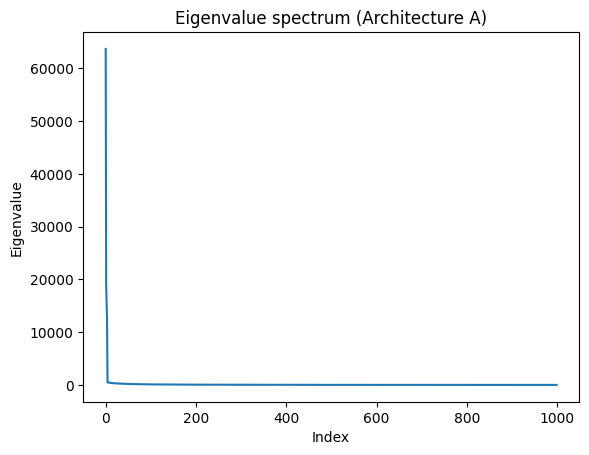

Architecture B
Condition number: 19494.004
Trace: 5192.1626


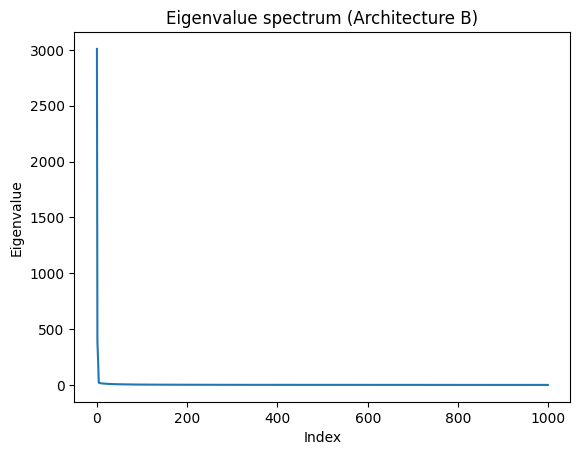

In [5]:
def analyze_ntk(Theta, name):
    eigvals = np.linalg.eigvalsh(Theta)
    cond = eigvals.max() / eigvals.min()
    trace = eigvals.sum()

    print(f"{name}")
    print("Condition number:", cond)
    print("Trace:", trace)

    plt.figure()
    plt.plot(np.sort(eigvals)[::-1])
    plt.title(f"Eigenvalue spectrum ({name})")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.show()

    return eigvals, cond, trace

eigA, condA, traceA = analyze_ntk(ThetaA, "Architecture A")
eigB, condB, traceB = analyze_ntk(ThetaB, "Architecture B")

Architecture A
Condition number: 15235.556
Trace: 151712.3


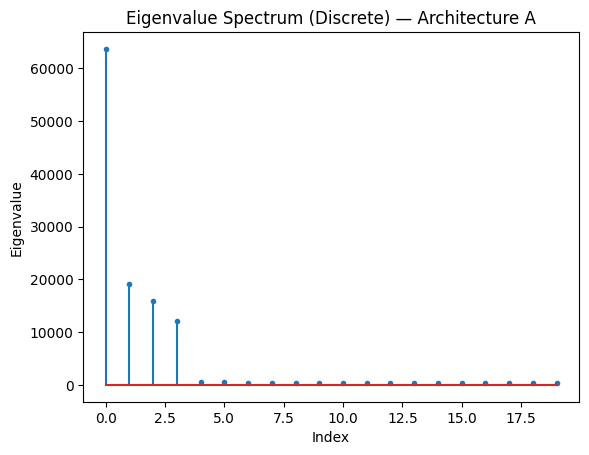

Architecture B
Condition number: 19494.004
Trace: 5192.163


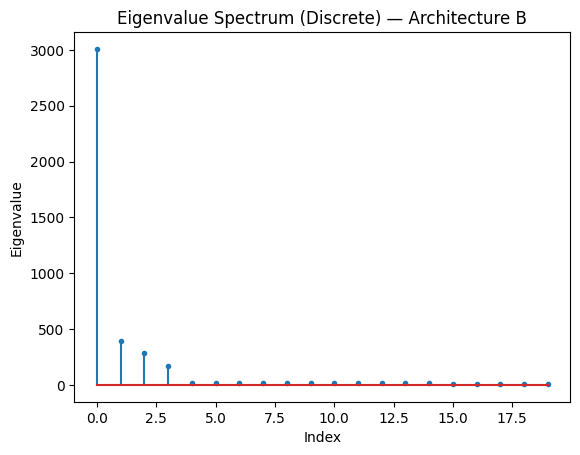

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_ntk_discrete(Theta, name, xlim = None):
    eigvals = np.linalg.eigvalsh(Theta)
    eigvals_sorted = np.sort(eigvals)[::-1]

    cond = eigvals_sorted[0] / eigvals_sorted[-1]
    trace = eigvals_sorted.sum()

    print(f"{name}")
    print("Condition number:", cond)
    print("Trace:", trace)

    figure_eigevalues = eigvals_sorted[xlim[0]:xlim[1]] if xlim else eigvals_sorted
    range_fig = range(xlim[0], xlim[1]) if xlim else range(len(eigvals_sorted))

    # ---- discrete spectrum plot ----
    plt.figure()
    markerline, stemlines, baseline = plt.stem(
        range_fig,
        figure_eigevalues
    )
    plt.setp(markerline, markersize=3)
    plt.title(f"Eigenvalue Spectrum — {name}")
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.show()

    return eigvals_sorted, cond, trace

xlim = (0, 20)  # Set x-axis limits for better visualization

eigA, condA, traceA = analyze_ntk_discrete(ThetaA, "Architecture A - First 20", xlim=xlim)
eigB, condB, traceB = analyze_ntk_discrete(ThetaB, "Architecture B - First 20", xlim=xlim)


Architecture A
Condition number: 15235.556
Trace: 151712.3


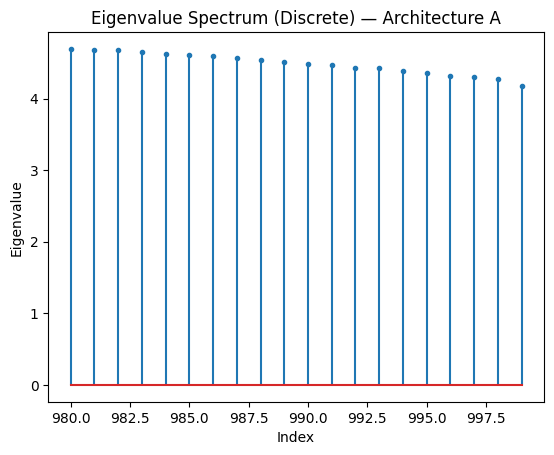

Architecture B
Condition number: 19494.004
Trace: 5192.163


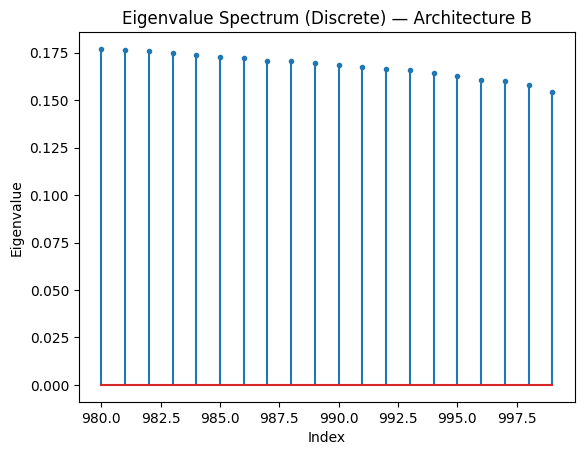

In [ ]:
xlim = (980, 1000)  # Set x-axis limits for better visualization

eigA, condA, traceA = analyze_ntk_discrete(ThetaA, "Architecture A - Last 20", xlim=xlim)
eigB, condB, traceB = analyze_ntk_discrete(ThetaB, "Architecture B - Last 20", xlim=xlim)


1000